# Oscar — are the duplicate rows real duplicates?

26 Sep 2026. The Taiwan data has 35 rows that exactly match another row (see
`01-working`). Two explanations:

* **coincidence:** two different customers who happen to have the same values
  in all 24 columns, or
* **a real duplicate:** the same customer recorded twice, or a data error.

Plan: (1) look at what the duplicates actually are, (2) give each column a
probability distribution, (3) use it to work out how likely one coincidental
repeat is, and how likely it is to see 35. All three steps are below; the
summary comes first.

## Summary of findings

**What we found**

* **35 exact duplicate pairs** (70 rows): every one is a pair, with no triples
  or larger groups. None are normal accounts. 30 are *no-activity* accounts (all
  bills and payments 0) and 5 have *the same amounts every month*.
* **Chance explains about half.** Treating each column as an independent draw
  from its own distribution, within each activity type, about **16
  coincidental pairs** are expected. P(at least one repeated row) ≈ 1, but
  **P(35 or more) ≈ 2 × 10⁻⁵**, so coincidence alone does not explain what we
  see.
* **The 5 same-every-month pairs are almost certainly real duplicates:**
  fewer than 0.01 are expected by chance, even with the independence
  assumption relaxed. The no-activity accounts have about twice as many pairs
  as chance predicts (30 vs ~16, p ≈ 0.001), so roughly 14 of those are
  probably real too. The test cannot say which ones.
* **Near-duplicates exist too** (found by a separate check, not yet in this
  notebook): IDs 12431, 12433 and 14295 are identical **except the default
  label** (12433 did not default, the other two did). IDs 1698 and 25892 are
  identical except that repayment status is -1 in one and -2 in the other.

**Impact on data quality**

* **Size:** small. 35 rows out of 30,000 (0.1%), and only among unusual
  low-activity accounts. Summary statistics and overall default rates barely
  change.
* **Leakage between train and test (the main risk for Sprint 1):** if one copy
  of a customer lands in the training data and the other in the test data, the
  model is tested on a customer it has already seen, and the test score is too
  good. De-duplicate before splitting.
* **Label noise:** the 12431/12433/14295 group suggests the same customer can
  appear with *different* labels. That is worse than a plain duplicate: no model
  can get both right, and it casts some doubt on how the label was recorded.
* **Inconsistent codes:** -1 vs -2 for otherwise identical accounts fits the
  earlier finding that `PAY_*` uses codes (-2, 0) the documentation does not
  explain. Treat the fine distinctions between -2, -1 and 0 with caution.
* **Only exact matches are counted.** Records that differ in one column (like
  12433) are missed, so 35 is a **lower bound** on the duplication.

**Recommendation (to agree with the group):** drop one row from each of the 5
same-every-month pairs at least. Drop duplicates before any train/test split.
Mention the near-duplicates and label conflict in the report's data-cleaning
section. Next check: pairs that differ in only one or two columns, and which
columns differ.

In [6]:
from pathlib import Path
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent
RAW = ROOT / "data" / "raw"

taiwan = pd.read_excel(RAW / "taiwan-credit-default" / "default of credit card clients.xls",
                       header=1, index_col="ID")
Y = "default payment next month"
COLS = list(taiwan.columns)          # all 24 columns (ID is the index, not a column)
taiwan.shape

(30000, 24)

## Step 1: what the duplicates look like

`duplicated()` marks a row as True if an **earlier** row has the same values,
so it counts the *extra copies*. With `keep=False` it marks **every** row that
has a twin, including the first one. So:

* `duplicated().sum()` = extra copies
* `duplicated(keep=False).sum()` = all rows involved

In [7]:
print("extra copies:      ", taiwan.duplicated().sum())
print("rows with a twin:  ", taiwan.duplicated(keep=False).sum())

dups = taiwan[taiwan.duplicated(keep=False)].copy()

# Grouping by all 24 columns puts identical rows in the same group.
# size() counts how many rows are in each group.
group_sizes = dups.groupby(COLS).size()
print("groups:            ", len(group_sizes))
group_sizes.value_counts().rename("number of groups").rename_axis("rows in group")

extra copies:       35
rows with a twin:   70
groups:             35


rows in group
2    35
Name: number of groups, dtype: int64

So every duplicate is a **pair**: 35 groups of exactly 2. There are no
triples or larger groups.

Next, number the pairs and show them side by side. `ngroup()` gives each
group a number, and `reset_index()` turns the ID back into a normal column so
we can see which customer IDs are paired.

In [8]:
dups["pair"] = dups.groupby(COLS).ngroup()
pairs = dups.reset_index().sort_values(["pair", "ID"])

pd.set_option("display.max_columns", 30)
pairs.set_index(["pair", "ID"])

LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  \
pair ID                                                                     
0    12431      20000    1          2         2   24      2      2      4   
     14295      20000    1          2         2   24      2      2      4   
1    1760       50000    1          2         2   26      1     -2     -2   
     10251      50000    1          2         2   26      1     -2     -2   
2    7171       50000    2          1         2   23      1     -2     -2   
...               ...  ...        ...       ...  ...    ...    ...    ...   
32   27967     360000    2          1         2   27      1     -2     -2   
33   18326     360000    2          1         2   29      1     -2     -2   
     22163     360000    2          1         2   29      1     -2     -2   
34   840       500000    1          1         1   43      1     -2     -2   
     7320      500000    1          1         1   43      1     -2     -2   

            PAY_4  PAY_5  PAY_6  BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  \
pair ID                                                                       
0    12431      4      4      4       1650       1650       1650       1650   
     14295      4      4      4       1650       1650       1650       1650   
1    1760      -2     -2     -2          0          0          0          0   
     10251     -2     -2     -2          0          0          0          0   
2    7171      -2     -2     -2          0          0          0          0   
...           ...    ...    ...        ...        ...        ...        ...   
32   27967     -2     -2     -2          0          0          0          0   
33   18326     -2     -2     -2          0          0          0          0   
     22163     -2     -2     -2          0          0          0          0   
34   840       -2     -2     -2          0          0          0          0   
     7320      -2     -2     -2          0          0          0          0   

            BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  PAY_AMT4  \
pair ID                                                                    
0    12431       1650       1650         0         0         0         0   
     14295       1650       1650         0         0         0         0   
1    1760           0          0         0         0         0         0   
     10251          0          0         0         0         0         0   
2    7171           0          0         0         0         0         0   
...               ...        ...       ...       ...       ...       ...   
32   27967          0          0         0         0         0         0   
33   18326          0          0         0         0         0         0   
     22163          0          0         0         0         0         0   
34   840            0          0         0         0         0         0   
     7320           0          0         0         0         0         0   

            PAY_AMT5  PAY_AMT6  default payment next month  
pair ID                                                     
0    12431         0         0                           1  
     14295         0         0                           1  
1    1760          0         0                           0  
     10251         0         0                           0  
2    7171          0         0                           0  
...              ...       ...                         ...  
32   27967         0         0                           0  
33   18326         0         0                           0  
     22163         0         0                           0  
34   840           0         0                           1  
     7320          0         0                           1  

[70 rows x 24 columns]

## What kind of accounts are they?

Looking down the table, most pairs have **every bill and payment amount equal
to 0**: the card was not used at all in the six months. Below, each row is
sorted into one of three activity types:

* `no activity`: all 12 money columns are 0
* `same every month`: money columns non-zero, but each column has the same
  value every month (e.g. bill 390, paid 390, six times over)
* `varied`: anything else, i.e. a normal account

In [9]:
MONEY = [c for c in COLS if c.startswith(("BILL_AMT", "PAY_AMT"))]
BILLS = [c for c in COLS if c.startswith("BILL_AMT")]
PAYS  = [c for c in COLS if c.startswith("PAY_AMT")]

def activity(df):
    no_activity = (df[MONEY] == 0).all(axis=1)
    # nunique(axis=1) counts distinct values along each row; 1 means all the same
    constant = (df[BILLS].nunique(axis=1) == 1) & (df[PAYS].nunique(axis=1) == 1)
    return np.select([no_activity, constant], ["no activity", "same every month"], default="varied")

taiwan["activity"] = activity(taiwan)
dups["activity"] = activity(dups)

pd.DataFrame({
    "whole dataset (rows)": taiwan["activity"].value_counts(),
    "duplicate pairs":      dups.groupby("pair")["activity"].first().value_counts(),
}).fillna(0).astype(int)

,whole dataset (rows),duplicate pairs
activity,,
no activity,795,30
same every month,296,5
varied,28909,0


In [10]:
# Among the no-activity accounts, which repayment-status patterns appear?
taiwan[taiwan["activity"] == "no activity"][["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]] \
    .value_counts()

PAY_0  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6
 1     -2     -2     -2     -2     -2       495
-2     -2     -2     -2     -2     -2       300
Name: count, dtype: int64

## Findings from step 1 (rough)

* 35 pairs, no triples or larger groups.
* 30 of the 35 pairs are **no-activity** accounts. Only 795 of the 30,000
  customers have no activity at all, so duplicates are heavily concentrated in
  this small group.
* For a no-activity account, 17 of the 24 columns are **fixed**: 12 money
  columns at 0, and `PAY_2`…`PAY_6` all -2 (`PAY_0` is either 1 or -2). Two
  such customers therefore only need to match on the remaining 7
  columns: `LIMIT_BAL`, `SEX`, `EDUCATION`, `MARRIAGE`, `AGE`, `PAY_0` and the
  label. That is much easier to do by chance.
* The other 5 pairs have identical amounts every month. Four pay off the same
  small bill each month (e.g. 390), which looks like a fixed monthly charge.
  One has an unpaid bill of 1,650 and is in arrears (pair 0). Also low-variety.
* Paired IDs are not next to each other (e.g. 1212 and 21882), so this does
  not look like a row accidentally copied twice in a row.

**What this means for step 2:** columns can't be treated as independent across
all 24. A model that multiplies 24 separate probabilities would call a
coincidence almost impossible, which is wrong for inactive accounts. It is
better to model it in two parts: (a) the chance an account has no activity (or
the same bill every month), then (b) the chance two such accounts match on
the few columns that are still free.

## Step 2: a distribution for each column

**Assumption (agreed):** within each activity type, the columns are
independent. Each customer is like a separate random draw for each column.
The activity type is chosen first, because "no activity" forces 17 columns to
be the same and treating those as independent would make no sense.

Every column here takes a limited set of values: `SEX` is 1 or 2, `LIMIT_BAL`
is a round amount like 50,000, and so on. So each column is modelled as a
**categorical distribution**: value *k* has probability *p_k*, estimated by
the share of customers with that value. (For a two-value column such as `SEX`
or the label, this is a Bernoulli distribution.)

**Chance that two customers match on one column.** Draw two customers
independently. Both get value *k* with probability *p_k × p_k*, so

$$P(\text{match on column}) = \sum_k p_k^2 .$$

Example: 60% women and 40% men gives 0.6² + 0.4² = 0.52. Because the columns
are independent, the chance of matching on **every** column is the product of
the per-column chances. A column that is fixed within a group has one value
with p = 1, so its match chance is 1 and it drops out.

In [11]:
def match_prob(values):
    """Chance two independent draws from this column's distribution are equal: sum of p_k squared."""
    p = values.value_counts(normalize=True)
    return (p ** 2).sum()


def column_table(df, cols):
    """One row per column: how many distinct values, and the chance two customers match on it."""
    return pd.DataFrame({
        "distinct values": [df[c].nunique() for c in cols],
        "P(match)":        [match_prob(df[c]) for c in cols],
    }, index=cols)


no_act = taiwan[taiwan["activity"] == "no activity"]
na_table = column_table(no_act, COLS)
na_table.round(4)

,distinct values,P(match)
LIMIT_BAL,47,0.0501
SEX,2,0.5346
EDUCATION,6,0.3820
MARRIAGE,4,0.4923
AGE,48,0.0352
PAY_0,2,0.5301
PAY_2,1,1.0000
PAY_3,1,1.0000
PAY_4,1,1.0000
PAY_5,1,1.0000


Columns with 1 distinct value (P(match) = 1) are the 17 fixed ones. The 7
free ones are what a coincidental match actually has to agree on. `AGE` and
`LIMIT_BAL` do most of the work: each has about a 1 in 20-30 chance of
matching.

### The same-every-month group

For these accounts each bill column holds one value repeated six times, and
the same goes for payments. Treating `BILL_AMT1`…`BILL_AMT6` as six
independent columns would count one number six times, so we use a single
"monthly bill" variable and a single "monthly payment" variable instead. The
other columns, including all six `PAY_*` status columns, are kept separate.

In [12]:
const = taiwan[taiwan["activity"] == "same every month"].copy()
const["monthly bill"] = const["BILL_AMT1"]
const["monthly payment"] = const["PAY_AMT1"]
CONST_COLS = [c for c in COLS if c not in MONEY] + ["monthly bill", "monthly payment"]

const_table = column_table(const, CONST_COLS)
const_table.round(4)

,distinct values,P(match)
LIMIT_BAL,41,0.0494
SEX,2,0.5051
EDUCATION,4,0.3686
MARRIAGE,4,0.4881
AGE,43,0.0334
PAY_0,7,0.2491
PAY_2,5,0.3448
PAY_3,9,0.2685
PAY_4,9,0.2486
PAY_5,9,0.2484


### Varied accounts

Everything else: all 24 columns, each with its own distribution. The money
columns take thousands of different values, so matches are very unlikely.

In [13]:
varied = taiwan[taiwan["activity"] == "varied"]
varied_table = column_table(varied, COLS)
varied_table.sort_values("P(match)").head(8).round(6)   # the 8 hardest columns to match on

,distinct values,P(match)
BILL_AMT1,22697,0.001890
BILL_AMT2,22319,0.003626
BILL_AMT3,22001,0.005295
BILL_AMT4,21521,0.007027
BILL_AMT5,20981,0.008927
BILL_AMT6,20578,0.012566
PAY_AMT1,7939,0.027498
PAY_AMT2,7896,0.028906


## Step 3: from one pair to the whole dataset

A group of *n* customers contains *n(n−1)/2* possible pairs. If each pair
matches with chance *q* (the product of the column probabilities above), the
**expected number of coincidental duplicate pairs** is

$$\lambda = \frac{n(n-1)}{2}\, q .$$

When there are many pairs and each has a tiny chance of matching, the
number that actually match follows a **Poisson distribution** with mean λ.
That gives the test:

* **Null hypothesis:** every duplicate is a coincidence between different
  customers.
* **p-value:** P(Poisson(λ) ≥ observed pairs). The chance of seeing at least
  this many duplicate pairs if they were all coincidences. A tiny p-value
  means coincidence alone is not a believable explanation.

In [14]:
from scipy import stats

observed_pairs = dups.groupby("pair")["activity"].first().value_counts()

groups = {
    "no activity":      (no_act, na_table),
    "same every month": (const,  const_table),
    "varied":           (varied, varied_table),
}
rows = {}
for name, (df, table) in groups.items():
    n = len(df)
    q = table["P(match)"].prod()           # independence: multiply across columns
    lam = n * (n - 1) / 2 * q
    obs = observed_pairs.get(name, 0)
    rows[name] = {"customers n": n, "P(a pair matches) q": q, "expected pairs λ": lam,
                  "observed pairs": obs,
                  "p-value P(≥ observed)": stats.poisson.sf(obs - 1, lam)}   # sf(k) = P(X > k)

results = pd.DataFrame(rows).T
results

,customers n,P(a pair matches) q,expected pairs λ,observed pairs,p-value P(≥ observed)
no activity,795.0,4.980511e-05,1.571924e+01,30.0,8.661277e-04
same every month,296.0,2.954211e-10,1.289809e-05,5.0,2.974681e-27
varied,28909.0,1.908237e-29,7.973583e-21,0.0,1.000000e+00


In [15]:
# The whole dataset: add up the expected pairs from the three groups.
N = len(taiwan)
lam_total = results["expected pairs λ"].sum()
q_total = lam_total / (N * (N - 1) / 2)       # chance two random customers match, averaged over all pairs
observed_total = taiwan[COLS].duplicated().sum()

print(f"P(two random customers are identical)   = {q_total:.2e}")
print(f"expected coincidental pairs, λ           = {lam_total:.1f}")
print(f"P(at least one repeated row)             = {1 - np.exp(-lam_total):.6f}")
print(f"P(exactly {observed_total} repeated rows)              = {stats.poisson.pmf(observed_total, lam_total):.2e}")
print(f"P({observed_total} or more repeated rows)              = {stats.poisson.sf(observed_total - 1, lam_total):.2e}")

P(two random customers are identical)   = 3.49e-08
expected coincidental pairs, λ           = 15.7
P(at least one repeated row)             = 1.000000
P(exactly 35 repeated rows)              = 1.08e-05
P(35 or more repeated rows)              = 1.89e-05


### Checking the Poisson shortcut by simulation

The Poisson formula is an approximation. To check it, simulate the null
hypothesis directly: draw 795 fake no-activity customers, each column
independently from its fitted distribution, count the duplicate rows, and
repeat 10,000 times. If the formula is right, the simulated average should be
close to λ, and the share of simulations reaching the observed 30 should be
close to the p-value.

In [16]:
rng = np.random.default_rng(0)     # fixed seed so the result is the same every run
FREE = na_table.index[na_table["distinct values"] > 1]   # the fixed columns can't differ, so skip them
n_sims, n = 10_000, len(no_act)

# Draw every column for every simulation at once, as value codes 0, 1, 2, ...
# Each column gets an array of shape (n_sims, n).
codes = np.zeros((n_sims, n), dtype=np.int64)
for c in FREE:
    p = no_act[c].value_counts(normalize=True)
    draws = rng.choice(len(p), size=(n_sims, n), p=p.values)
    codes = codes * len(p) + draws  # combine the columns into one number per fake customer

# Duplicates in a simulation = customers minus distinct customers.
sim_dups = np.array([n - len(np.unique(row)) for row in codes])

obs_na = observed_pairs["no activity"]
print(f"simulated mean duplicate pairs: {sim_dups.mean():.1f}  (Poisson λ = {results.loc['no activity', 'expected pairs λ']:.1f})")
print(f"share of simulations with ≥ {obs_na}:  {(sim_dups >= obs_na).mean():.4f}  "
      f"(Poisson p-value = {results.loc['no activity', 'p-value P(≥ observed)']:.4f})")

simulated mean duplicate pairs: 15.2  (Poisson λ = 15.7)
share of simulations with ≥ 30:  0.0006  (Poisson p-value = 0.0009)


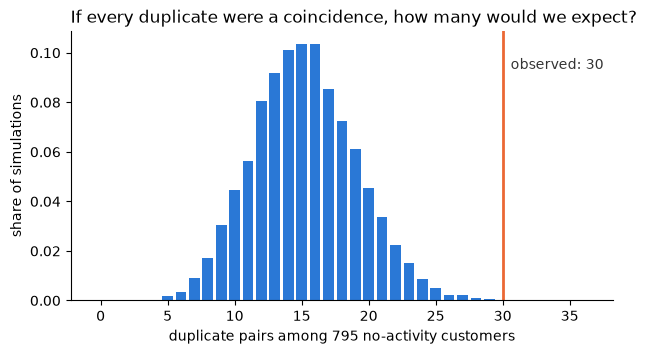

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 3.5))
counts = np.bincount(sim_dups)
ax.bar(np.arange(len(counts)), counts / n_sims, color="#2a78d6", width=0.8)
ax.axvline(obs_na, color="#eb6834", linewidth=2)
ax.text(obs_na, ax.get_ylim()[1] * 0.9, f"  observed: {obs_na}", color="0.2", va="top")
ax.set_xlabel("duplicate pairs among 795 no-activity customers")
ax.set_ylabel("share of simulations")
ax.set_title("If every duplicate were a coincidence, how many would we expect?", loc="left")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

### How much does the independence assumption matter?

For the same-every-month accounts, the six `PAY_*` status columns are
obviously **not** independent: an account that pays off the same bill each
month is -1 ("paid on time") every month. Treating them as independent makes a
match look rarer than it is. As a rough check, treat the six status columns as
**one** variable (the whole pattern) and see whether the conclusion changes.

In [18]:
PAY_STATUS = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
const["status pattern"] = const[PAY_STATUS].astype(str).agg(",".join, axis=1)
relaxed_cols = [c for c in CONST_COLS if c not in PAY_STATUS] + ["status pattern"]

q_relaxed = column_table(const, relaxed_cols)["P(match)"].prod()
lam_relaxed = len(const) * (len(const) - 1) / 2 * q_relaxed
print(f"expected pairs, PAY_* independent:  {results.loc['same every month', 'expected pairs λ']:.2e}")
print(f"expected pairs, PAY_* as one pattern: {lam_relaxed:.2e}")
print(f"p-value for 5 observed:              {stats.poisson.sf(4, lam_relaxed):.2e}")

expected pairs, PAY_* independent:  1.29e-05
expected pairs, PAY_* as one pattern: 7.16e-03
p-value for 5 observed:              1.56e-13


## Conclusions (rough)

**The two numbers asked for** (whole dataset, columns independent within each
activity type):

* **P(a repeated row):** the chance that two randomly chosen customers are
  identical is about **3.5 × 10⁻⁸**. But there are 450 million pairs of
  customers, so about **16 coincidental pairs are expected**, and P(at least
  one repeated row) ≈ 1. Some duplicates should appear even if every row is a
  different person.
* **P(what we see, 35 repeated rows):** P(exactly 35) ≈ 1 × 10⁻⁵ and
  **P(35 or more) ≈ 2 × 10⁻⁵**. Coincidence alone is not a believable
  explanation for all 35.

**By group:**

| group | expected by chance | observed | verdict |
|---|---|---|---|
| no activity | ~16 | 30 | about twice what chance predicts (p ≈ 0.001, simulation agrees) |
| same every month | ~0 (below 0.01 even with `PAY_*` treated as one pattern) | 5 | almost certainly real duplicates |
| varied | ~0 | 0 | nothing to explain |

**So:** roughly half of the no-activity pairs could be chance. The 5
same-every-month pairs, and probably about 14 of the no-activity pairs, are
likely to be real duplicates or data errors. For the no-activity pairs the
test cannot say *which* individual pairs are real.

**Caveats:**

* Independence is an assumption. Where columns are really related (credit
  limit rises with age; married people are older), real matches are more likely
  than the model says, so some of the no-activity excess may be down to that.
  The same-every-month result survives relaxing it (the check above).
* The distributions were estimated from data that includes the duplicates.
  This slightly *raises* the match probabilities, which favours coincidence, so
  it makes the test more cautious, not less.

**For the group:** 35 rows out of 30,000 (0.1%) will hardly change any model,
but it should go in the report's data-cleaning section. Options: drop the 5
clear duplicates, drop one row from every pair, or keep everything and say
why. To decide together.